# 05 — Descriptive Analysis

This notebook provides descriptive evidence on cross-market mispricing between Bitcoin prediction markets and the Deribit-implied probability proxy.

The analysis focuses on sample composition, probability distributions, mispricing patterns, horizon differences, and descriptive tables/figures used in the thesis.

In [2]:
# ============================================================
# Imports and project configuration
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from importlib import reload
import config
reload(config)

from config import *

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

print("Project directory:", BASE_DIR)
print("Final data directory:", FINAL_DIR)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)

for folder in [FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

Project directory: /Users/giannandreadestefano/TESI FINANCE/Thesis Project
Final data directory: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/data/final
Figures directory: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures
Tables directory: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables


In [3]:
# ============================================================
# Load matched datasets
# ============================================================

unified_path = FINAL_DIR / "unified_prediction_market_deribit_matched.csv"

poly_terminal_path = PROCESSED_DIR / "polymarket_deribit_matched_terminal.csv"
poly_path_dep_path = PROCESSED_DIR / "polymarket_deribit_matched_path_dependent.csv"
poly_terminal_short_path = PROCESSED_DIR / "polymarket_deribit_matched_terminal_short.csv"
poly_terminal_very_short_path = PROCESSED_DIR / "polymarket_deribit_matched_terminal_very_short.csv"

kalshi_matched_path = PROCESSED_DIR / "kalshi_deribit_matched.csv"

df_unified = pd.read_csv(unified_path)
df_poly_terminal = pd.read_csv(poly_terminal_path)
df_poly_path_dep = pd.read_csv(poly_path_dep_path)
df_poly_terminal_short = pd.read_csv(poly_terminal_short_path)
df_poly_terminal_very_short = pd.read_csv(poly_terminal_very_short_path)
df_kalshi = pd.read_csv(kalshi_matched_path)

date_cols_unified = ["date", "observation_time", "expiration_time"]
for col in date_cols_unified:
    df_unified[col] = pd.to_datetime(df_unified[col], utc=True, errors="coerce")

for df in [
    df_poly_terminal,
    df_poly_path_dep,
    df_poly_terminal_short,
    df_poly_terminal_very_short,
]:
    for col in ["date", "datetime", "end_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

for col in ["observation_date", "observation_time", "close_time"]:
    if col in df_kalshi.columns:
        df_kalshi[col] = pd.to_datetime(
            df_kalshi[col],
            utc=True,
            errors="coerce",
        )

# ------------------------------------------------------------
# Validate timestamped Kalshi input
# ------------------------------------------------------------

assert df_kalshi["ticker"].is_unique

assert df_kalshi["price_source"].eq(
    "first_timestamped_trade"
).all()

assert df_kalshi["minutes_after_open"].between(
    0,
    30,
    inclusive="both",
).all()

assert len(df_unified) == (
    len(df_poly_terminal)
    + len(df_poly_path_dep)
    + len(df_kalshi)
)

assert (
    df_unified.loc[
        df_unified["market"].eq("kalshi"),
        "contract_id",
    ].nunique()
    == len(df_kalshi)
)

print("Descriptive input validation passed.")

print("=" * 70)
print("Loaded descriptive analysis datasets")
print("=" * 70)

print("Unified:")
print(f"  Rows: {len(df_unified):,}")
print(f"  Contracts: {df_unified['contract_id'].nunique():,}")
print(f"  Date range: {df_unified['date'].min()} -> {df_unified['date'].max()}")

print("\nPolymarket terminal:")
print(f"  Rows: {len(df_poly_terminal):,}")
print(f"  Markets: {df_poly_terminal['market_id'].nunique():,}")

print("\nPolymarket path-dependent:")
print(f"  Rows: {len(df_poly_path_dep):,}")
print(f"  Markets: {df_poly_path_dep['market_id'].nunique():,}")

print("\nKalshi timestamped, first trade within 30 minutes:")
print(f"  Rows: {len(df_kalshi):,}")
print(f"  Tickers: {df_kalshi['ticker'].nunique():,}")

Descriptive input validation passed.
Loaded descriptive analysis datasets
Unified:
  Rows: 33,107
  Contracts: 6,566
  Date range: 2024-03-09 00:00:00+00:00 -> 2026-06-04 00:00:00+00:00

Polymarket terminal:
  Rows: 19,649
  Markets: 2,847

Polymarket path-dependent:
  Rows: 10,323
  Markets: 584

Kalshi timestamped, first trade within 30 minutes:
  Rows: 3,135
  Tickers: 3,135


In [4]:
# ============================================================
# Sample overview by market and contract type
# ============================================================

sample_overview = (
    df_unified
    .groupby(["market", "contract_type"])
    .agg(
        observations=("contract_id", "size"),
        contracts=("contract_id", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        avg_prob_market=("prob_market", "mean"),
        avg_prob_deribit=("prob_deribit", "mean"),
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        avg_tau_days=("tau", lambda x: x.mean() * 365),
    )
    .reset_index()
)

sample_overview[
    [
        "avg_prob_market",
        "avg_prob_deribit",
        "avg_mispricing",
        "median_mispricing",
        "avg_tau_days",
    ]
] = sample_overview[
    [
        "avg_prob_market",
        "avg_prob_deribit",
        "avg_mispricing",
        "median_mispricing",
        "avg_tau_days",
    ]
].round(4)

sample_overview_path = TABLES_DIR / "descriptive_sample_overview.csv"
sample_overview.to_csv(sample_overview_path, index=False)

display(sample_overview)

print(f"Saved sample overview table to: {sample_overview_path}")

,market,contract_type,observations,contracts,start_date,end_date,avg_prob_market,avg_prob_deribit,avg_mispricing,median_mispricing,avg_tau_days
0,kalshi,between,3080,3080,2025-02-04 00:00:00+00:00,2026-06-04 00:00:00+00:00,0.1852,0.1234,0.0618,0.0205,0.0363
1,kalshi,greater,15,15,2025-10-27 00:00:00+00:00,2026-06-04 00:00:00+00:00,0.1787,0.0000,0.1787,0.0100,0.0334
2,kalshi,less,40,40,2025-02-13 00:00:00+00:00,2026-06-04 00:00:00+00:00,0.1528,0.0351,0.1177,0.0100,0.0348
3,polymarket,above,10585,1532,2024-03-09 00:00:00+00:00,2026-06-03 00:00:00+00:00,0.4891,0.4814,0.0077,0.0029,3.7069
4,polymarket,dip,4513,274,2024-04-26 00:00:00+00:00,2026-06-01 00:00:00+00:00,0.1478,0.0810,0.0667,0.0335,47.3327
5,polymarket,range,9064,1315,2025-02-08 00:00:00+00:00,2026-06-03 00:00:00+00:00,0.1077,0.1004,0.0074,0.0027,3.6792
6,polymarket,reach,5810,310,2024-04-03 00:00:00+00:00,2026-06-01 00:00:00+00:00,0.1870,0.0884,0.0986,0.0263,60.8628


Saved sample overview table to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/descriptive_sample_overview.csv


In [5]:
# ============================================================
# Descriptive summary by market
# ============================================================

summary_by_market = (
    df_unified
    .groupby("market")
    .agg(
        observations=("contract_id", "size"),
        contracts=("contract_id", "nunique"),
        dates=("date", "nunique"),
        avg_prob_market=("prob_market", "mean"),
        avg_prob_deribit=("prob_deribit", "mean"),
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        sd_mispricing=("mispricing", "std"),
        avg_tau_days=("tau", lambda x: x.mean() * 365),
    )
    .reset_index()
)

summary_by_market[
    [
        "avg_prob_market",
        "avg_prob_deribit",
        "avg_mispricing",
        "median_mispricing",
        "sd_mispricing",
        "avg_tau_days",
    ]
] = summary_by_market[
    [
        "avg_prob_market",
        "avg_prob_deribit",
        "avg_mispricing",
        "median_mispricing",
        "sd_mispricing",
        "avg_tau_days",
    ]
].round(4)

summary_by_market_path = TABLES_DIR / "descriptive_summary_by_market.csv"
summary_by_market.to_csv(summary_by_market_path, index=False)

display(summary_by_market)

print(f"Saved market summary table to: {summary_by_market_path}")

,market,observations,contracts,dates,avg_prob_market,avg_prob_deribit,avg_mispricing,median_mispricing,sd_mispricing,avg_tau_days
0,kalshi,3135,3135,485,0.1847,0.1216,0.0631,0.0199,0.1477,0.0363
1,polymarket,29972,3431,813,0.2638,0.2297,0.0341,0.0080,0.0971,21.3470


Saved market summary table to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/descriptive_summary_by_market.csv


In [6]:
# ============================================================
# Descriptive summary by empirical sample
# ============================================================

empirical_samples = {
    "Polymarket terminal": df_poly_terminal,
    "Polymarket terminal short-horizon": df_poly_terminal_short,
    "Polymarket terminal very-short-horizon": df_poly_terminal_very_short,
    "Polymarket path-dependent": df_poly_path_dep,
    "Kalshi timestamped, first trade within 30 minutes": df_kalshi,
}

sample_rows = []

for sample_name, df_sample in empirical_samples.items():
    contract_col = "market_id" if "market_id" in df_sample.columns else "ticker"
    
    sample_rows.append({
        "sample": sample_name,
        "observations": len(df_sample),
        "contracts": df_sample[contract_col].nunique(),
        "start_date": df_sample["date"].min() if "date" in df_sample.columns else df_sample["observation_date"].min(),
        "end_date": df_sample["date"].max() if "date" in df_sample.columns else df_sample["observation_date"].max(),
        "avg_prob_market": df_sample["prob_market"].mean(),
        "avg_prob_deribit": df_sample["prob_deribit"].mean(),
        "avg_mispricing": df_sample["mispricing"].mean(),
        "median_mispricing": df_sample["mispricing"].median(),
        "sd_mispricing": df_sample["mispricing"].std(),
        "avg_tau_days": df_sample["tau"].mean() * 365,
    })

summary_by_empirical_sample = pd.DataFrame(sample_rows)

numeric_cols = [
    "avg_prob_market",
    "avg_prob_deribit",
    "avg_mispricing",
    "median_mispricing",
    "sd_mispricing",
    "avg_tau_days",
]

summary_by_empirical_sample[numeric_cols] = (
    summary_by_empirical_sample[numeric_cols].round(4)
)

summary_by_empirical_sample_path = (
    TABLES_DIR / "descriptive_summary_by_empirical_sample.csv"
)

summary_by_empirical_sample.to_csv(
    summary_by_empirical_sample_path,
    index=False,
)

display(summary_by_empirical_sample)

print(f"Saved empirical sample summary to: {summary_by_empirical_sample_path}")

,sample,observations,contracts,start_date,end_date,avg_prob_market,avg_prob_deribit,avg_mispricing,median_mispricing,sd_mispricing,avg_tau_days
0,Polymarket terminal,19649,2847,2024-03-09 00:00:00+00:00,2026-06-03 00:00:00+00:00,0.3132,0.3056,0.0076,0.0028,0.0398,3.6941
1,Polymarket terminal short-horizon,19649,2847,2024-03-09 00:00:00+00:00,2026-06-03 00:00:00+00:00,0.3132,0.3056,0.0076,0.0028,0.0398,3.6941
2,Polymarket terminal very-short-horizon,19616,2847,2024-03-09 00:00:00+00:00,2026-06-03 00:00:00+00:00,0.3129,0.3054,0.0075,0.0027,0.0398,3.6780
3,Polymarket path-dependent,10323,584,2024-04-03 00:00:00+00:00,2026-06-01 00:00:00+00:00,0.1698,0.0852,0.0846,0.0303,0.1431,54.9478
4,"Kalshi timestamped, first trade within 30 minutes",3135,3135,2025-02-04 00:00:00+00:00,2026-06-04 00:00:00+00:00,0.1847,0.1216,0.0631,0.0199,0.1477,0.0363


Saved empirical sample summary to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/descriptive_summary_by_empirical_sample.csv


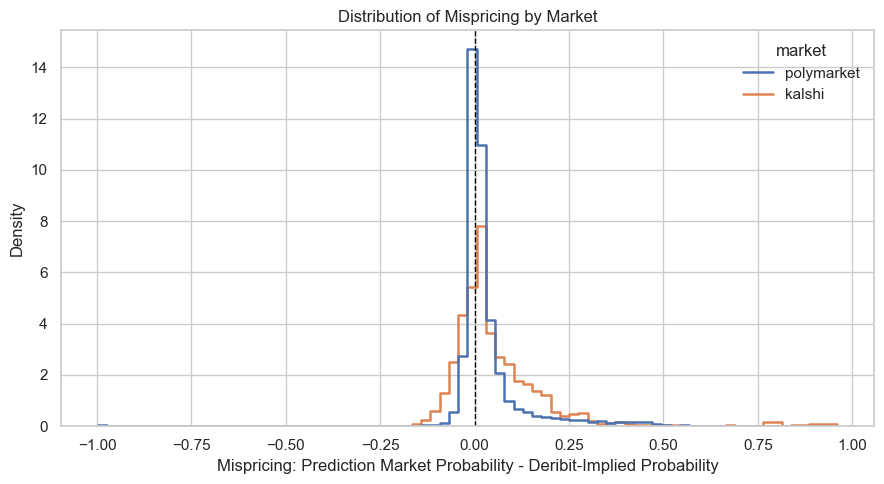

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/mispricing_distribution_by_market.png


In [7]:
# ============================================================
# Figure: Mispricing distribution by market
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

plot_df = df_unified.copy()

sns.histplot(
    data=plot_df,
    x="mispricing",
    hue="market",
    bins=80,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    ax=ax,
)

ax.axvline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Distribution of Mispricing by Market")
ax.set_xlabel("Mispricing: Prediction Market Probability - Deribit-Implied Probability")
ax.set_ylabel("Density")

fig.tight_layout()

mispricing_distribution_path = FIGURES_DIR / "mispricing_distribution_by_market.png"
fig.savefig(mispricing_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {mispricing_distribution_path}")

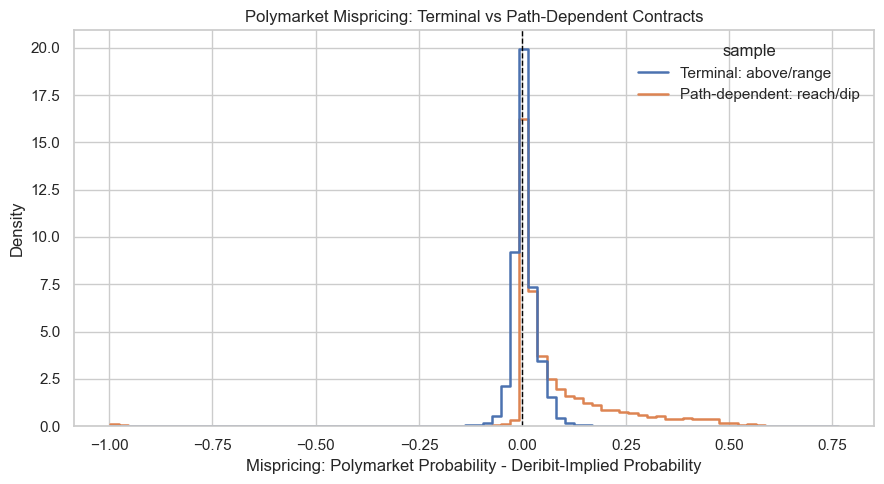

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/polymarket_terminal_vs_path_dependent.png


In [8]:
# ============================================================
# Figure: Polymarket terminal vs path-dependent mispricing
# ============================================================

poly_plot_df = pd.concat(
    [
        df_poly_terminal.assign(sample="Terminal: above/range"),
        df_poly_path_dep.assign(sample="Path-dependent: reach/dip"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=poly_plot_df,
    x="mispricing",
    hue="sample",
    bins=80,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    ax=ax,
)

ax.axvline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Polymarket Mispricing: Terminal vs Path-Dependent Contracts")
ax.set_xlabel("Mispricing: Polymarket Probability - Deribit-Implied Probability")
ax.set_ylabel("Density")

fig.tight_layout()

poly_terminal_vs_path_path = FIGURES_DIR / "polymarket_terminal_vs_path_dependent.png"
fig.savefig(poly_terminal_vs_path_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {poly_terminal_vs_path_path}")

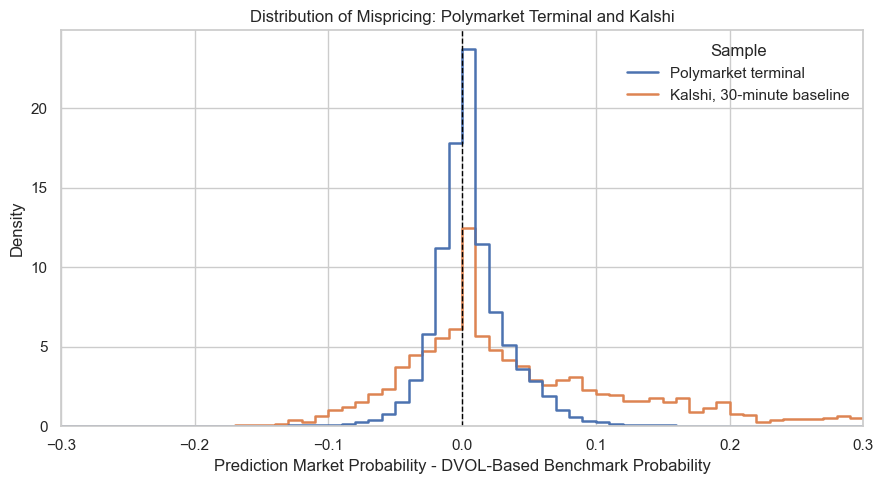

Polymarket terminal vs Kalshi mispricing distribution
Rows plotted: 22,784
sample
Polymarket terminal           19649
Kalshi, 30-minute baseline     3135
Name: count, dtype: int64

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/mispricing_distribution_by_market_zoomed.png


In [9]:
# ============================================================
# Figure: Polymarket terminal vs Kalshi mispricing distribution
# ============================================================

df_distribution_market = pd.concat(
    [
        df_poly_terminal[["mispricing"]].assign(
            sample="Polymarket terminal"
        ),
        df_kalshi[["mispricing"]].assign(
            sample="Kalshi, 30-minute baseline"
        ),
    ],
    ignore_index=True,
).dropna(subset=["mispricing"])

sample_order = [
    "Polymarket terminal",
    "Kalshi, 30-minute baseline",
]

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df_distribution_market,
    x="mispricing",
    hue="sample",
    hue_order=sample_order,
    bins=60,
    binrange=(-0.30, 0.30),
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    ax=ax,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_xlim(-0.30, 0.30)

ax.set_title(
    "Distribution of Mispricing: Polymarket Terminal and Kalshi"
)
ax.set_xlabel(
    "Prediction Market Probability - "
    "DVOL-Based Benchmark Probability"
)
ax.set_ylabel("Density")

legend = ax.get_legend()
if legend is not None:
    legend.set_title("Sample")

fig.tight_layout()

mispricing_distribution_zoomed_path = (
    FIGURES_DIR
    / "mispricing_distribution_by_market_zoomed.png"
)

fig.savefig(
    mispricing_distribution_zoomed_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("=" * 70)
print("Polymarket terminal vs Kalshi mispricing distribution")
print("=" * 70)
print(f"Rows plotted: {len(df_distribution_market):,}")
print(
    df_distribution_market["sample"]
    .value_counts(dropna=False)
)
print(f"\nSaved figure to: {mispricing_distribution_zoomed_path}")

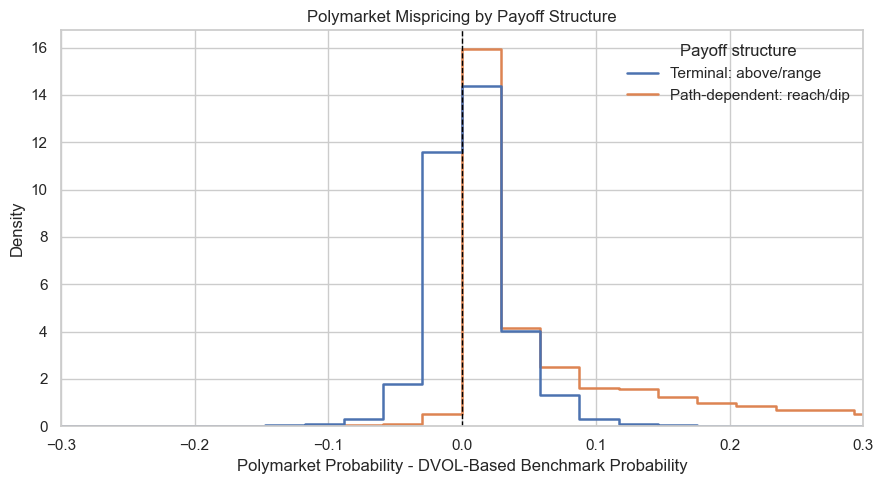

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/polymarket_terminal_vs_path_dependent_zoomed.png


In [10]:
# ============================================================
# Figure: Zoomed Polymarket terminal vs path-dependent mispricing
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=poly_plot_df,
    x="mispricing",
    hue="sample",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    ax=ax,
)

legend = ax.get_legend()

if legend is not None:
    legend.set_title("Payoff structure")

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlim(-0.30, 0.30)

ax.set_title("Polymarket Mispricing by Payoff Structure")
ax.set_xlabel(
    "Polymarket Probability - DVOL-Based Benchmark Probability"
)
ax.set_ylabel("Density")

fig.tight_layout()

poly_terminal_vs_path_zoomed_path = (
    FIGURES_DIR / "polymarket_terminal_vs_path_dependent_zoomed.png"
)
fig.savefig(poly_terminal_vs_path_zoomed_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {poly_terminal_vs_path_zoomed_path}")

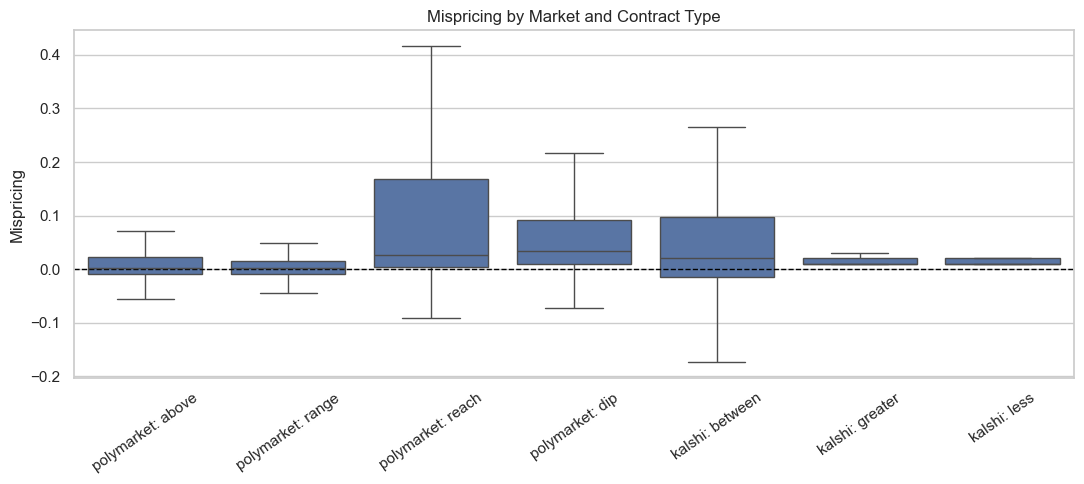

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/mispricing_by_contract_type_boxplot.png


In [11]:
# ============================================================
# Figure: Mispricing by contract type
# ============================================================

contract_order = [
    "above",
    "range",
    "reach",
    "dip",
    "between",
    "greater",
    "less",
]

plot_df = df_unified.copy()
plot_df["market_contract_type"] = (
    plot_df["market"] + ": " + plot_df["contract_type"]
)

plot_order = [
    "polymarket: above",
    "polymarket: range",
    "polymarket: reach",
    "polymarket: dip",
    "kalshi: between",
    "kalshi: greater",
    "kalshi: less",
]

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=plot_df,
    x="market_contract_type",
    y="mispricing",
    order=plot_order,
    showfliers=False,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Mispricing by Market and Contract Type")
ax.set_xlabel("")
ax.set_ylabel("Mispricing")
ax.tick_params(axis="x", rotation=35)

fig.tight_layout()

mispricing_boxplot_path = FIGURES_DIR / "mispricing_by_contract_type_boxplot.png"
fig.savefig(mispricing_boxplot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {mispricing_boxplot_path}")

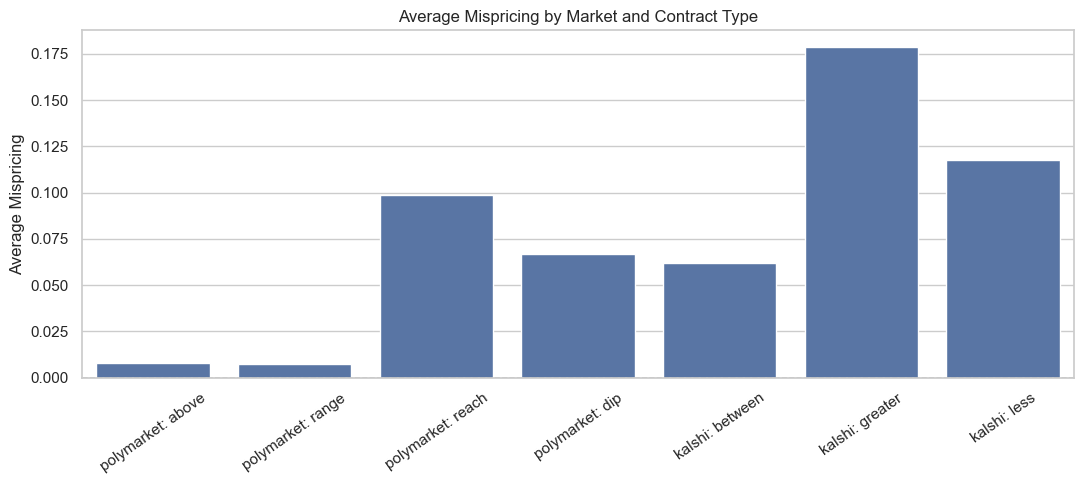

,market_contract_type,avg_mispricing,median_mispricing,observations
0,polymarket: above,0.0077,0.0029,10585
1,polymarket: range,0.0074,0.0027,9064
2,polymarket: reach,0.0986,0.0263,5810
3,polymarket: dip,0.0667,0.0335,4513
4,kalshi: between,0.0618,0.0205,3080
5,kalshi: greater,0.1787,0.0100,15
6,kalshi: less,0.1177,0.0100,40


Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/average_mispricing_by_contract_type.png


In [12]:
# ============================================================
# Figure: Average mispricing by contract type
# ============================================================

contract_summary_plot = (
    plot_df
    .groupby("market_contract_type")
    .agg(
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        observations=("contract_id", "size"),
    )
    .reindex(plot_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=contract_summary_plot,
    x="market_contract_type",
    y="avg_mispricing",
    order=plot_order,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Average Mispricing by Market and Contract Type")
ax.set_xlabel("")
ax.set_ylabel("Average Mispricing")
ax.tick_params(axis="x", rotation=35)

fig.tight_layout()

mispricing_barplot_path = FIGURES_DIR / "average_mispricing_by_contract_type.png"
fig.savefig(mispricing_barplot_path, dpi=300, bbox_inches="tight")

plt.show()

display(contract_summary_plot.round(4))

print(f"Saved figure to: {mispricing_barplot_path}")

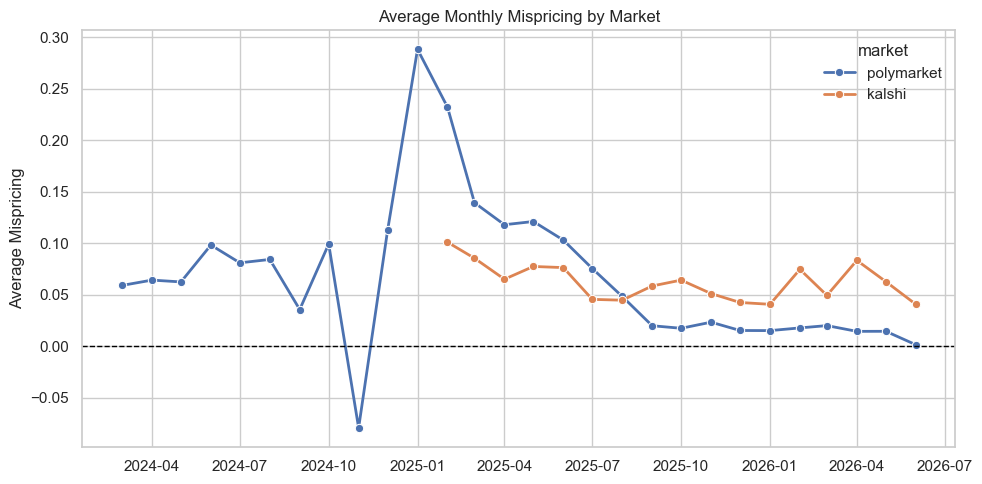

,month,market,avg_mispricing,median_mispricing,observations
35,2026-02-01 00:00:00+00:00,kalshi,0.074635,0.016657,255
36,2026-02-01 00:00:00+00:00,polymarket,0.017764,0.007030,2382
37,2026-03-01 00:00:00+00:00,kalshi,0.049337,0.010000,371
38,2026-03-01 00:00:00+00:00,polymarket,0.020012,0.004876,1368
39,2026-04-01 00:00:00+00:00,kalshi,0.083342,0.010000,410
40,2026-04-01 00:00:00+00:00,polymarket,0.014416,0.003015,786
41,2026-05-01 00:00:00+00:00,kalshi,0.062743,0.028872,271
42,2026-05-01 00:00:00+00:00,polymarket,0.014475,0.003143,1503
43,2026-06-01 00:00:00+00:00,kalshi,0.040716,0.010000,42
44,2026-06-01 00:00:00+00:00,polymarket,0.001440,0.000500,152


Saved table to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/monthly_mispricing_by_market.csv
Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/average_monthly_mispricing_by_market.png


In [13]:
# ============================================================
# Figure: Average monthly mispricing by market
# ============================================================

df_unified_ts = df_unified.copy()
df_unified_ts["month"] = pd.to_datetime(
    df_unified_ts["date"].dt.strftime("%Y-%m-01"),
    utc=True,
)

monthly_mispricing_market = (
    df_unified_ts
    .groupby(["month", "market"])
    .agg(
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        observations=("contract_id", "size"),
    )
    .reset_index()
)

monthly_mispricing_market["month"] = pd.to_datetime(
    monthly_mispricing_market["month"],
    utc=True,
)

monthly_mispricing_market_path = (
    TABLES_DIR / "monthly_mispricing_by_market.csv"
)
monthly_mispricing_market.to_csv(monthly_mispricing_market_path, index=False)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_mispricing_market,
    x="month",
    y="avg_mispricing",
    hue="market",
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Average Monthly Mispricing by Market")
ax.set_xlabel("")
ax.set_ylabel("Average Mispricing")

fig.tight_layout()

monthly_mispricing_market_fig_path = (
    FIGURES_DIR / "average_monthly_mispricing_by_market.png"
)
fig.savefig(monthly_mispricing_market_fig_path, dpi=300, bbox_inches="tight")

plt.show()

display(monthly_mispricing_market.tail(10))

print(f"Saved table to: {monthly_mispricing_market_path}")
print(f"Saved figure to: {monthly_mispricing_market_fig_path}")

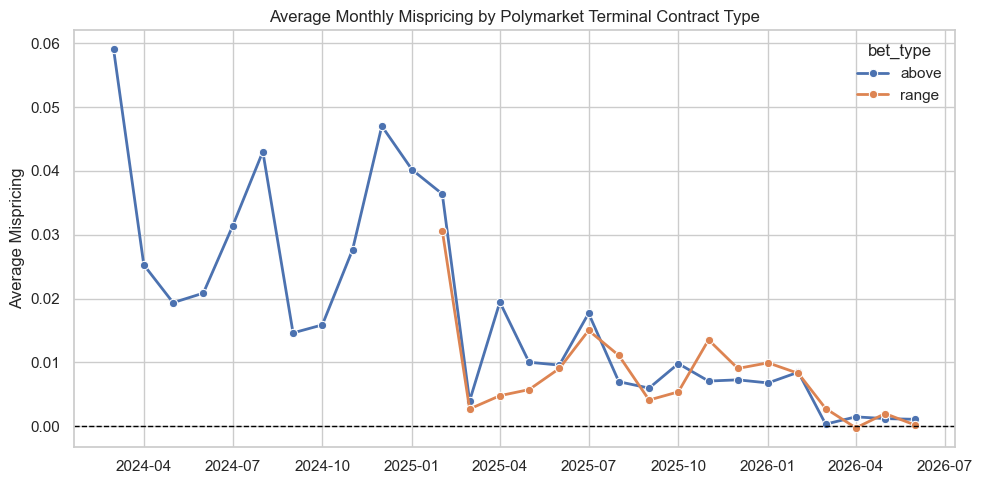

,month,bet_type,avg_mispricing,median_mispricing,observations,markets
35,2026-02-01 00:00:00+00:00,above,0.008473,0.007889,948,198
36,2026-02-01 00:00:00+00:00,range,0.008287,0.004370,817,171
37,2026-03-01 00:00:00+00:00,above,0.000338,-0.000246,539,126
38,2026-03-01 00:00:00+00:00,range,0.002782,0.003500,363,96
39,2026-04-01 00:00:00+00:00,above,0.001474,0.000111,309,99
40,2026-04-01 00:00:00+00:00,range,-0.000252,-0.001624,190,63
41,2026-05-01 00:00:00+00:00,above,0.001201,-0.000500,473,110
42,2026-05-01 00:00:00+00:00,range,0.001990,0.000500,369,81
43,2026-06-01 00:00:00+00:00,above,0.001089,0.000500,66,33
44,2026-06-01 00:00:00+00:00,range,0.000178,0.000500,54,27


Saved table to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/monthly_mispricing_polymarket_terminal.csv
Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/average_monthly_mispricing_polymarket_terminal.png


In [14]:
# ============================================================
# Figure: Average monthly mispricing by terminal contract type
# ============================================================

df_poly_terminal_ts = df_poly_terminal.copy()

df_poly_terminal_ts["month"] = pd.to_datetime(
    df_poly_terminal_ts["date"].dt.strftime("%Y-%m-01"),
    utc=True,
)

monthly_poly_terminal_by_type = (
    df_poly_terminal_ts
    .groupby(["month", "bet_type"])
    .agg(
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        observations=("market_id", "size"),
        markets=("market_id", "nunique"),
    )
    .reset_index()
)

monthly_poly_terminal_by_type["month"] = pd.to_datetime(
    monthly_poly_terminal_by_type["month"],
    utc=True,
)

monthly_poly_terminal_path = (
    TABLES_DIR / "monthly_mispricing_polymarket_terminal.csv"
)

monthly_poly_terminal_by_type.to_csv(
    monthly_poly_terminal_path,
    index=False,
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_poly_terminal_by_type,
    x="month",
    y="avg_mispricing",
    hue="bet_type",
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Average Monthly Mispricing by Polymarket Terminal Contract Type"
)
ax.set_xlabel("")
ax.set_ylabel("Average Mispricing")

fig.tight_layout()

monthly_poly_terminal_fig_path = (
    FIGURES_DIR
    / "average_monthly_mispricing_polymarket_terminal.png"
)

fig.savefig(
    monthly_poly_terminal_fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(monthly_poly_terminal_by_type.tail(10))

print(f"Saved table to: {monthly_poly_terminal_path}")
print(f"Saved figure to: {monthly_poly_terminal_fig_path}")

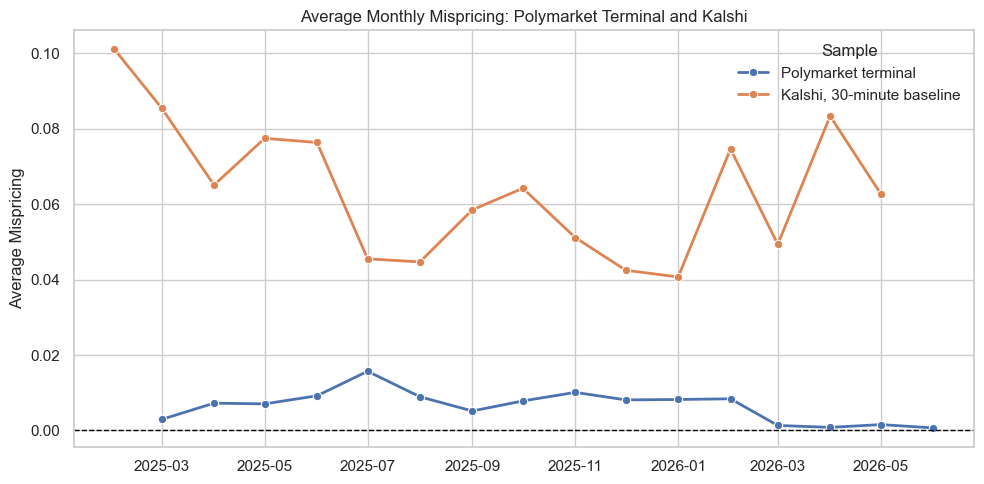

Filtered monthly mispricing: main empirical samples


,month,avg_mispricing,median_mispricing,observations,clusters,market
0,2025-02-01 00:00:00+00:00,0.101041,0.042000,110,25,"Kalshi, 30-minute baseline"
1,2025-03-01 00:00:00+00:00,0.085451,0.043024,138,31,"Kalshi, 30-minute baseline"
2,2025-04-01 00:00:00+00:00,0.065068,0.043125,131,30,"Kalshi, 30-minute baseline"
3,2025-05-01 00:00:00+00:00,0.077453,0.060466,122,31,"Kalshi, 30-minute baseline"
4,2025-06-01 00:00:00+00:00,0.076344,0.050692,129,30,"Kalshi, 30-minute baseline"
5,2025-07-01 00:00:00+00:00,0.045495,0.025304,148,31,"Kalshi, 30-minute baseline"
6,2025-08-01 00:00:00+00:00,0.044684,0.022145,159,31,"Kalshi, 30-minute baseline"
7,2025-09-01 00:00:00+00:00,0.058486,0.028422,134,30,"Kalshi, 30-minute baseline"
8,2025-10-01 00:00:00+00:00,0.064203,0.047999,160,30,"Kalshi, 30-minute baseline"
9,2025-11-01 00:00:00+00:00,0.051135,0.014541,186,30,"Kalshi, 30-minute baseline"



Minimum observations per sample-month: 100
Saved table to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/monthly_mispricing_main_samples_filtered.csv
Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/average_monthly_mispricing_by_market_filtered.png


In [15]:
# ============================================================
# Figure: Average monthly mispricing, main empirical samples
# ============================================================

MIN_MONTHLY_OBS = 100

# ------------------------------------------------------------
# Prepare Polymarket terminal observations
# ------------------------------------------------------------

df_poly_monthly = df_poly_terminal.copy()

df_poly_monthly["date"] = pd.to_datetime(
    df_poly_monthly["date"],
    utc=True,
    errors="coerce",
)

df_poly_monthly["month"] = pd.to_datetime(
    df_poly_monthly["date"].dt.strftime("%Y-%m-01"),
    utc=True,
)

monthly_poly_terminal = (
    df_poly_monthly
    .dropna(subset=["month", "mispricing"])
    .groupby("month")
    .agg(
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        observations=("mispricing", "size"),
        clusters=("market_id", "nunique"),
    )
    .reset_index()
)

monthly_poly_terminal["market"] = "Polymarket terminal"

# ------------------------------------------------------------
# Prepare Kalshi 30-minute baseline observations
# ------------------------------------------------------------

df_kalshi_monthly = df_kalshi.copy()

df_kalshi_monthly["observation_time"] = pd.to_datetime(
    df_kalshi_monthly["observation_time"],
    utc=True,
    errors="coerce",
)

df_kalshi_monthly["month"] = pd.to_datetime(
    df_kalshi_monthly["observation_time"].dt.strftime("%Y-%m-01"),
    utc=True,
)

monthly_kalshi_baseline = (
    df_kalshi_monthly
    .dropna(subset=["month", "mispricing"])
    .groupby("month")
    .agg(
        avg_mispricing=("mispricing", "mean"),
        median_mispricing=("mispricing", "median"),
        observations=("mispricing", "size"),
        clusters=("event_ticker", "nunique"),
    )
    .reset_index()
)

monthly_kalshi_baseline["market"] = (
    "Kalshi, 30-minute baseline"
)

# ------------------------------------------------------------
# Combine and filter sample-months
# ------------------------------------------------------------

monthly_mispricing_main_samples = pd.concat(
    [
        monthly_poly_terminal,
        monthly_kalshi_baseline,
    ],
    ignore_index=True,
)

monthly_mispricing_main_samples_filtered = (
    monthly_mispricing_main_samples[
        monthly_mispricing_main_samples["observations"]
        >= MIN_MONTHLY_OBS
    ]
    .sort_values(["market", "month"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Save underlying monthly table
# ------------------------------------------------------------

monthly_mispricing_main_samples_path = (
    TABLES_DIR
    / "monthly_mispricing_main_samples_filtered.csv"
)

monthly_mispricing_main_samples_filtered.to_csv(
    monthly_mispricing_main_samples_path,
    index=False,
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

sample_order = [
    "Polymarket terminal",
    "Kalshi, 30-minute baseline",
]

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_mispricing_main_samples_filtered,
    x="month",
    y="avg_mispricing",
    hue="market",
    hue_order=sample_order,
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Average Monthly Mispricing: "
    "Polymarket Terminal and Kalshi"
)
ax.set_xlabel("")
ax.set_ylabel("Average Mispricing")

legend = ax.get_legend()

if legend is not None:
    legend.set_title("Sample")

fig.tight_layout()

monthly_mispricing_market_filtered_fig_path = (
    FIGURES_DIR
    / "average_monthly_mispricing_by_market_filtered.png"
)

fig.savefig(
    monthly_mispricing_market_filtered_fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("=" * 70)
print("Filtered monthly mispricing: main empirical samples")
print("=" * 70)

display(monthly_mispricing_main_samples_filtered)

print(
    "\nMinimum observations per sample-month:",
    MIN_MONTHLY_OBS,
)
print(
    "Saved table to:",
    monthly_mispricing_main_samples_path,
)
print(
    "Saved figure to:",
    monthly_mispricing_market_filtered_fig_path,
)

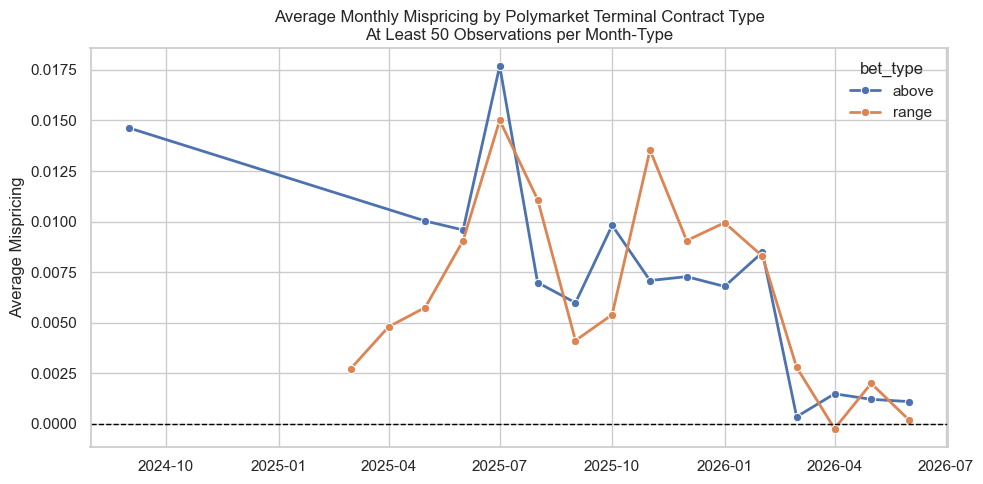

Saved figure to: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/figures/average_monthly_mispricing_polymarket_terminal_filtered.png


In [16]:
# ============================================================
# Figure: Filtered monthly mispricing by terminal contract type
# ============================================================

MIN_MONTHLY_CONTRACT_TYPE_OBS = 50

monthly_poly_terminal_filtered = (
    monthly_poly_terminal_by_type.loc[
        monthly_poly_terminal_by_type["observations"]
        >= MIN_MONTHLY_CONTRACT_TYPE_OBS
    ]
    .sort_values(["bet_type", "month"])
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_poly_terminal_filtered,
    x="month",
    y="avg_mispricing",
    hue="bet_type",
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Average Monthly Mispricing by Polymarket Terminal Contract Type\n"
    f"At Least {MIN_MONTHLY_CONTRACT_TYPE_OBS} Observations per Month-Type"
)
ax.set_xlabel("")
ax.set_ylabel("Average Mispricing")

fig.tight_layout()

monthly_poly_terminal_filtered_fig_path = (
    FIGURES_DIR
    / "average_monthly_mispricing_polymarket_terminal_filtered.png"
)

fig.savefig(
    monthly_poly_terminal_filtered_fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure to: {monthly_poly_terminal_filtered_fig_path}")

In [18]:
# ============================================================
# Final descriptive analysis export summary
# ============================================================

print("=" * 70)
print("Final descriptive analysis export summary")
print("=" * 70)

print("Input datasets:")
print(f"  Unified matched dataset: {unified_path}")
print(f"  Polymarket terminal:     {poly_terminal_path}")
print(f"  Polymarket path-dependent: {poly_path_dep_path}")
print("Kalshi timestamped, first trade within 30 minutes: "f"{kalshi_matched_path}")

print("\nSaved tables:")
print(f"  Sample overview:             {sample_overview_path}")
print(f"  Summary by market:           {summary_by_market_path}")
print(f"  Summary by empirical sample: {summary_by_empirical_sample_path}")
print(f"  Monthly by market:           {monthly_mispricing_market_path}")
print(f"  Monthly Polymarket terminal: {monthly_poly_terminal_path}")

print("\nSaved figures:")
print(f"  Distribution by market:              {mispricing_distribution_path}")
print(f"  Distribution by market zoomed:       {mispricing_distribution_zoomed_path}")
print(f"  Polymarket terminal vs path:         {poly_terminal_vs_path_path}")
print(f"  Polymarket terminal vs path zoomed:  {poly_terminal_vs_path_zoomed_path}")
print(f"  Contract type boxplot:               {mispricing_boxplot_path}")
print(f"  Contract type average barplot:       {mispricing_barplot_path}")
print(f"  Monthly by market:                   {monthly_mispricing_market_fig_path}")
print(f"  Monthly by market filtered:          {monthly_mispricing_market_filtered_fig_path}")
print(f"  Monthly Polymarket terminal:         {monthly_poly_terminal_fig_path}")
print(f"  Monthly Polymarket terminal filtered:{monthly_poly_terminal_filtered_fig_path}")

print("\nFinal descriptive sample:")
print(f"  Unified observations: {len(df_unified):,}")
print(f"  Unified contracts:    {df_unified['contract_id'].nunique():,}")
print(f"  Markets:              {df_unified['market'].nunique():,}")
print(f"  Date range:           {df_unified['date'].min()} -> {df_unified['date'].max()}")

print("\n05_descriptive_analysis.ipynb completed successfully.")

Final descriptive analysis export summary
Input datasets:
  Unified matched dataset: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/data/final/unified_prediction_market_deribit_matched.csv
  Polymarket terminal:     /Users/giannandreadestefano/TESI FINANCE/Thesis Project/data/processed/polymarket_deribit_matched_terminal.csv
  Polymarket path-dependent: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/data/processed/polymarket_deribit_matched_path_dependent.csv
Kalshi timestamped, first trade within 30 minutes: /Users/giannandreadestefano/TESI FINANCE/Thesis Project/data/processed/kalshi_deribit_matched.csv

Saved tables:
  Sample overview:             /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/descriptive_sample_overview.csv
  Summary by market:           /Users/giannandreadestefano/TESI FINANCE/Thesis Project/outputs/tables/descriptive_summary_by_market.csv
  Summary by empirical sample: /Users/giannandreadestefano/TESI FINANCE/Thesis Proje